<a href="https://www.kaggle.com/code/emmanuelniyioriolowo/4-classical-models?scriptVersionId=284500866" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/baseline-models/metrics_table.csv
/kaggle/input/baseline-models/__results__.html
/kaggle/input/baseline-models/__notebook__.ipynb
/kaggle/input/baseline-models/__output__.json
/kaggle/input/baseline-models/custom.css
/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv
/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_full.csv


# Functions

In [2]:
# Mean Absolute Error (MAE)
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Root Mean Squared Error (RMSE)
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Mean Absolute Percentage Error (MAPE)
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0  # avoid division by zero
    return (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

# Function to calculate all three metrics
def calculate_evaluation_metrics(y_true, y_pred):
    metrics = []
    metrics.append(mae(y_true, y_pred).round(2))
    metrics.append(rmse(y_true, y_pred).round(2))
    metrics.append(mape(y_true, y_pred).round(2))
    return metrics


# plot graph 
def plot_forecasts(forecast, title):
    """Function to plot the forecasts"""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train.index, y=train['confirmed_cases'], name="Train", line=dict(color='#1f77b4')))
    fig.add_trace(go.Scatter(x=test.index, y=test['confirmed_cases'], name="Test", line=dict(color='#2ca02c')))
    fig.add_trace(go.Scatter(x=test.index, y=forecast, name="Forecast", line=dict(color='#ff0000')))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                     width=650, title_x=0.5, height=400, xaxis_title='Date',
                     yaxis_title='Confirmed Cases')
    return fig.show()


metrics_table = pd.read_csv('/kaggle/input/baseline-models/metrics_table.csv')

In [3]:
# imports for diagnosis
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox


def residual_diagnostics(model_name, resid, max_acf_lags=48, lb_lags=None):
    """
    resid: 1d array-like residuals
    max_acf_lags: number of lags to show in ACF plot
    lb_lags: list or int of lags to run Ljung-Box on (if None, computed automatically)
    """
    resid = pd.Series(resid).dropna()
    n = len(resid)
    print(f"\n=== Residual diagnostics for: {model_name} ===")
    print(f"Number of residuals: {n}")
    print(f"Mean residual ~ {resid.mean():.4g}, std ~ {resid.std():.4g}\n")

    # --- ACF plot ---
    fig, ax = plt.subplots(figsize=(8,3.5))
    plot_acf(resid, lags=min(max_acf_lags, n-1), ax=ax, alpha=0.05)
    ax.set_title(f"{model_name} — Residual ACF")
    plt.tight_layout()
    plt.show()

    # --- QQ plot ---
    fig = sm.qqplot(resid, line='45', fit=True)
    plt.title(f"{model_name} — Q-Q plot of residuals")
    plt.tight_layout()
    plt.show()

    # --- Histogram + KDE ---
    fig, ax = plt.subplots(figsize=(6,3.5))
    ax.hist(resid, bins=30, density=True, alpha=0.7)
    try:
        resid.plot(kind='kde', ax=ax)  # pandas Series KDE
    except Exception:
        pass
    ax.set_title(f"{model_name} — Residual histogram (+ KDE)")
    plt.tight_layout()
    plt.show()

    # --- Ljung-Box test ---
    # choose reasonable lags if not provided: up to min(40, n//5)
    if lb_lags is None:
        max_lb = min(40, max(3, n // 5))
        lb_lags = list(range(1, max_lb + 1))
    elif isinstance(lb_lags, int):
        lb_lags = list(range(1, lb_lags + 1))

    lb_res = acorr_ljungbox(resid, lags=lb_lags, return_df=True)  # columns: lb_stat, lb_pvalue
    # show a subset of results: typically 10, 20, 30 if present
    def pick_rows(df, picks=(10,20,30)):
        rows = []
        for p in picks:
            if p in df.index:
                rows.append((p, df.loc[p, 'lb_stat'], df.loc[p, 'lb_pvalue']))
        return rows

    print("Ljung-Box test (selected lags):")
    picked = pick_rows(lb_res, picks=(5,10,20,30))
    if not picked:  # fallback show first 6
        print(lb_res.head(6))
    else:
        print(pd.DataFrame(picked, columns=["lag","lb_stat","lb_pvalue"]).to_string(index=False))

    # quick overall interpretation using a reasonable lag (e.g., lag = min(10, len//5))
    check_lag = min(10, max(1, n//5))
    if check_lag in lb_res.index:
        pval = lb_res.loc[check_lag, 'lb_pvalue']
        print(f"\nInterpretation (lag={check_lag}): Ljung-Box p-value = {pval:.4f}")
        if pval > 0.05:
            print("-> Fail to reject H0: residuals behave like white noise (good).")
        else:
            print("-> Reject H0: residuals show autocorrelation (model may miss structure).")
    else:
        print("\nCould not compute quick interpretation: chosen lag not present in results.")

    # return the full LB dataframe for further inspection if needed
    return lb_res

# Data Extraction and EDA

In [4]:
# read data into a dataframe
df = pd.read_csv('/kaggle/input/ncdc-lassa-fever-timeseries-20202025/lassa_fever_timeseries_minimal.csv')

# construct series dataframe
ts_data = df[['week_end_date', 'epi_week', 'confirmed_cases']].copy()
ts_data.columns = ['date', 'epi_week', 'confirmed_cases']

# Ensure datetime index
ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.set_index('date')
ts_data = ts_data.asfreq('W') # set frequency to weekly
ts_data

,epi_week,confirmed_cases
date,,
2020-01-05,1,18
2020-01-12,2,64
2020-01-19,3,81
2020-01-26,4,95
2020-02-02,5,104
...,...,...
2025-10-19,42,9
2025-10-26,43,11
2025-11-02,44,12


In [5]:
# Some basic EDA
print(ts_data.dtypes)
print(ts_data.isnull().sum())
print(ts_data.describe())

epi_week           int64
confirmed_cases    int64
dtype: object
epi_week           0
confirmed_cases    0
dtype: int64
         epi_week  confirmed_cases
count  307.000000       307.000000
mean    26.136808        20.540717
std     14.879500        25.897753
min      1.000000         0.000000
25%     13.000000         6.000000
50%     26.000000        10.000000
75%     39.000000        21.000000
max     53.000000       137.000000


In [6]:
# create and display plot 
fig =  px.line(ts_data, x=ts_data.index, y="confirmed_cases",
        title="Weekly Lassa Fever Cases (2020–2025)")
fig.show()

# Train Test Split

In [7]:
# Train Test Split
train = ts_data.iloc[:-int(len(ts_data)*0.2)].copy()
test = ts_data.iloc[-int(len(ts_data)*0.2):].copy()

# ETS

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== 1. Fit ETS Model =====

ets_model = ExponentialSmoothing(
    train['confirmed_cases'],
    trend='add',
    seasonal='add',
    seasonal_periods=52
).fit()

# ===== 2. Forecast =====

ets_forecast = ets_model.forecast(len(test))

# Attach forecast to test set
test['ets_forecasts'] = ets_forecast.values

# Plot the forecasts
plot_forecasts(test['ets_forecasts'], 'ETS')

# Calculate metrics and add to results dataframe
metrics_list = ['ETS'] + calculate_evaluation_metrics(test['confirmed_cases'], test['ets_forecasts'])
metrics_table.loc[len(metrics_table)] = metrics_list

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning:

Optimization failed to converge. Check mle_retvals.




=== Residual diagnostics for: ETS(A,A,A) ===
Number of residuals: 246
Mean residual ~ 0.0001802, std ~ 9.585



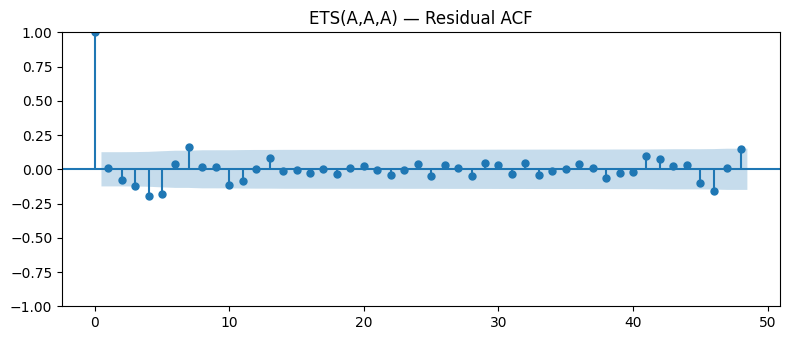

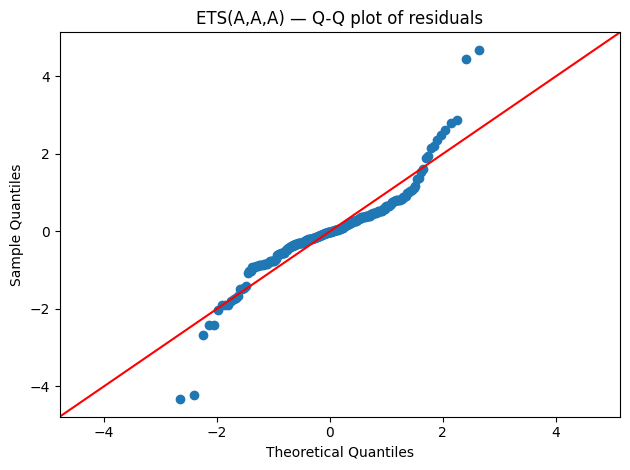

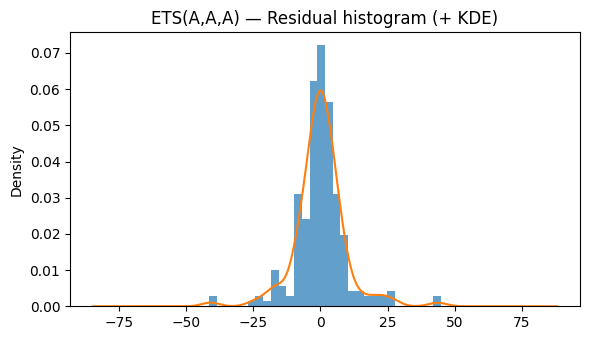

Ljung-Box test (selected lags):
 lag   lb_stat  lb_pvalue
   5 22.557041   0.000410
  10 33.388779   0.000234
  20 37.750973   0.009497
  30 41.005414   0.086814

Interpretation (lag=10): Ljung-Box p-value = 0.0002
-> Reject H0: residuals show autocorrelation (model may miss structure).


In [9]:
# sarima residual diagnostics 

# Extract residuals correctly
try:
    ets_resid = ets_model.resid
except AttributeError:
    ets_resid = train['confirmed_cases'] - ets_model.fittedvalues

# Run diagnostics
lb_ets    = residual_diagnostics("ETS(A,A,A)", ets_resid)

# Optional: save Ljung-Box tables to CSV for reporting
lb_ets.to_csv("lb_ets_resid.csv")

# SARIMA

In [10]:
# Import packages
from scipy.special import inv_boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build ARIMA model
sarima_model = SARIMAX(train['confirmed_cases'], order=(2, 1, 1),
              seasonal_order=(0, 1, 1, 52)).fit()
test['sarima_forecasts'] = sarima_model.forecast(len(test))

# Plot the forecasts
plot_forecasts(test['sarima_forecasts'], 'SARIMA Forecast')

# Calculate metrics and add to results dataframe
metrics_list = ['SARIMA'] + calculate_evaluation_metrics(test['confirmed_cases'], test['sarima_forecasts'])
metrics_table.loc[len(metrics_table)] = metrics_list

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning:

Non-invertible starting seasonal moving average Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals




=== Residual diagnostics for: SARIMA (2,1,1)(0,1,1,52) ===
Number of residuals: 246
Mean residual ~ 1.279, std ~ 12.17



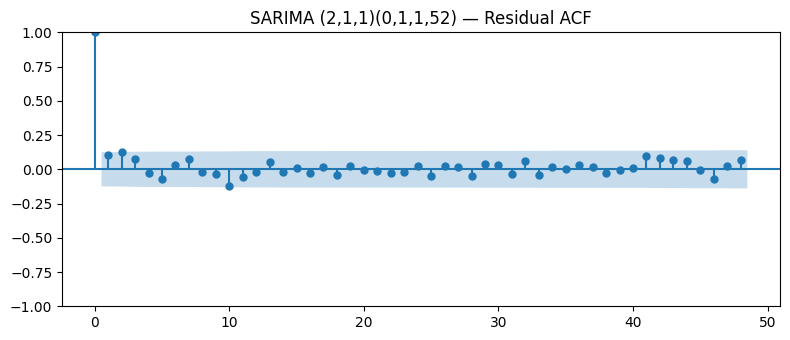

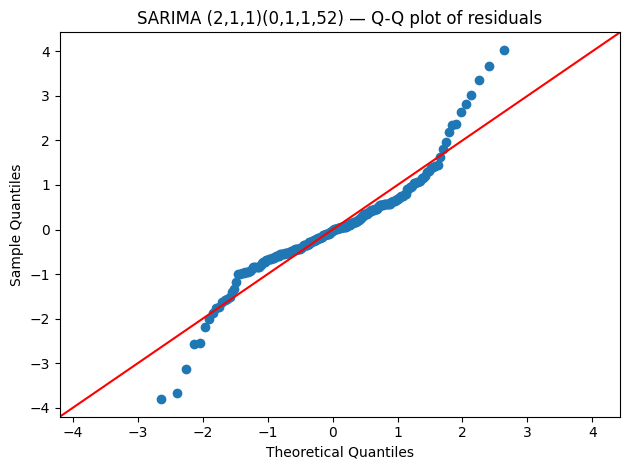

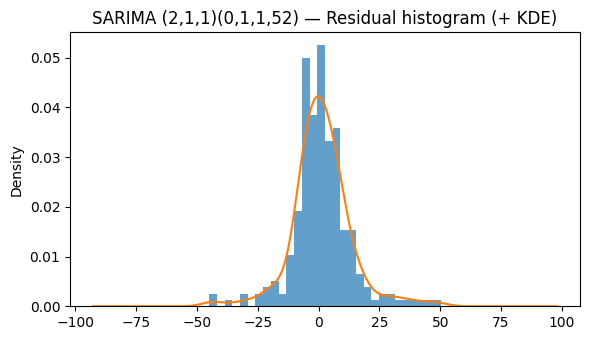

Ljung-Box test (selected lags):
 lag   lb_stat  lb_pvalue
   5  9.552348   0.088960
  10 15.415702   0.117625
  20 18.157713   0.577020
  30 20.815343   0.893573

Interpretation (lag=10): Ljung-Box p-value = 0.1176
-> Fail to reject H0: residuals behave like white noise (good).


In [11]:
# sarima residual diagnostics 

# extract residuals correctly
sarima_resid = sarima_model.resid

# run diagnostics
lb_sarima = residual_diagnostics("SARIMA (2,1,1)(0,1,1,52)", sarima_resid)

# save Ljung-Box tables to CSV for reporting
lb_sarima.to_csv("lb_sarima_resid.csv")

In [12]:
metrics_table.to_csv('metrics_table.csv', index=False)
metrics_table

,Model,MAE,RMSE,MAPE
0,Naive,16.33,26.37,60.30
1,Average,16.20,20.94,129.03
2,Drift,17.69,27.12,69.84
3,Seasonal Naive,8.74,15.53,49.24
4,Seasonal Mean,7.91,12.25,44.11
5,ETS,8.06,12.79,43.90
6,SARIMA,7.64,12.45,44.46


# Summary 

The first model was fit using SARIMA (0,1,1)(0,1,1,52) - gotten from the ACF and PACF plots - however, p-values on the Ljung-Box test were consistently below 0.05, which prompted me to adjust the model to (2,1,1)(0,1,1,52), yielding significantly better results.

From the table of results, it is clear that, on average, SARIMA performed better throughout all the main metrics: MAE, MSE, RMSE, and MAPE.
However, its performance was very close to the Seasonal Mean model when compared with baseline models. While the MAE of SARIMA was a bit lower, 7.64 vs. 7.91. In RMSE and MAPE, the Seasonal Mean model outperformed the former with respective values of 12.25 and 44.11 for the Seasonal Mean model and 14.25 and 44.46 for SARIMA.